In [1]:
# Name: Jackson Irungu Maina
# Reg No: ST61/55297/2025
# Programme: ST61 - Master of Data Science
# School: School of Science and Technology
# Course: Data Mining and Big Data , CSA 806 (Year 1 Sem 2 )
# Task: Module 5

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('fiia.csv')

# Filter for Kenyan data to maintain local context
kenya_df = df[df['country'] == 'Kenya'].copy()

# Inspect the first few rows
kenya_df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [17]:
# Drop non-analytical columns (ID, Country name, Year)
features = kenya_df.drop(columns=['uniqueid', 'country', 'year'])

# Separate the target (what we want to visualize)
target = features['bank_account']
features = features.drop(columns=['bank_account'])

# Identify categorical features (including 'string' for newer Pandas versions)
categorical_cols = features.select_dtypes(include=['object', 'string']).columns

# Encode categorical features into numeric values
le = LabelEncoder()
for col in categorical_cols:
    features[col] = le.fit_transform(features[col].astype(str))

# View the processed features table
features.head()

,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,0,1,3,24,0,5,2,3,8
1,0,0,5,70,0,1,4,0,4
2,1,1,5,26,1,3,3,5,8
3,0,1,5,34,0,1,2,2,3
4,1,0,8,26,1,0,3,2,5


In [18]:
# 1. Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 2. Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pc_results = pca.fit_transform(features_scaled)

# 3. Create a DataFrame for the new components
pca_df = pd.DataFrame(data=pc_results, columns=['PC1', 'PC2'])
pca_df['Bank Account'] = target.values

print("PCA transformation complete.")

PCA transformation complete.


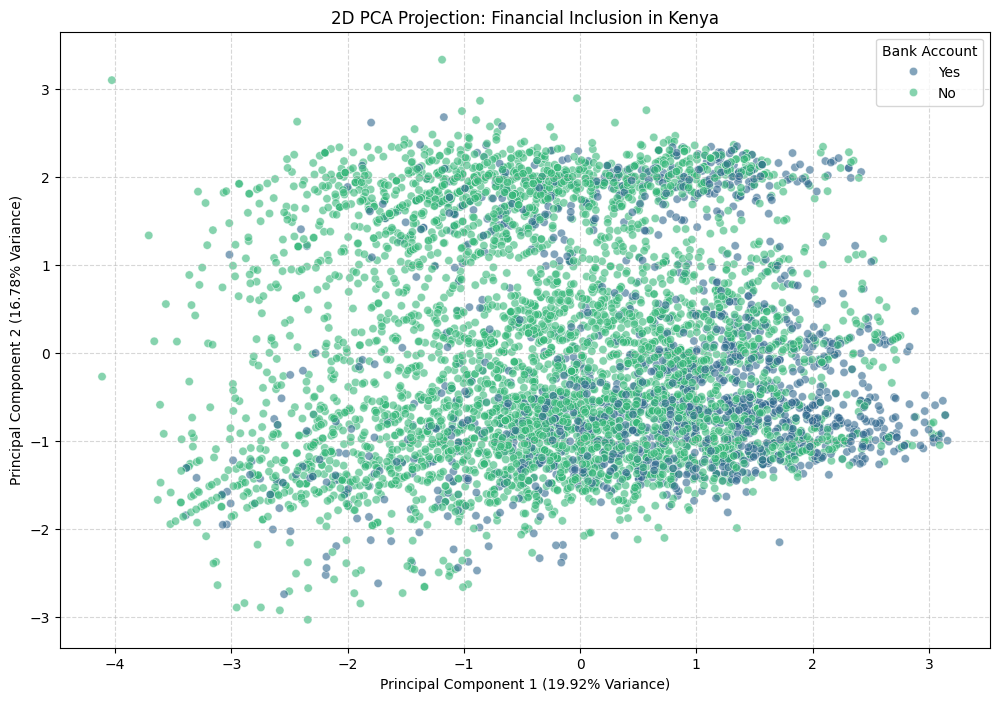

In [19]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Bank Account', 
    data=pca_df, 
    palette='viridis', 
    alpha=0.6
)

# Extract variance ratios for axis labels
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title('2D PCA Projection: Financial Inclusion in Kenya')
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
# Total Variance Explained
total_var = (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]) * 100
print(f"Total variance captured by these 2 components: {total_var:.2f}%")

# Feature Loadings: Which variables drive PC1?
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features.columns
)

print("\nTop 3 variables that influence Principal Component 1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(3))

Total variance captured by these 2 components: 36.70%

Top 3 variables that influence Principal Component 1:
education_level      0.554013
location_type        0.493817
age_of_respondent    0.382172
Name: PC1, dtype: float64
